In [1]:
import cv2
import numpy as np
from scipy.special import comb

class LezamaVPDetector:
    def __init__(self, image):
        self.img = image
        self.gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
        self.width, self.height = self.gray.shape[1], self.gray.shape[0]
        self.epsilon = 1.0  # Seuil NFA
        self.tau = 30       # Seuil pour segments courts

    def detect_lsd(self):
        """ Étape 2.1 : Détection initiale avec LSD """
        lsd = cv2.createLineSegmentDetector(0)
        lines, _, _, _ = lsd.detect(self.gray)
        # On convertit en liste de [x1, y1, x2, y2]
        return [l[0] for l in lines] if lines is not None else []

    def compute_nfa(self, n, k, p):
        """ Calcul de la loi binomiale pour le NFA (Sect 2.1) """
        proba = 0
        for i in range(int(k), int(n) + 1):
            # Loi binomiale : P(X >= k)
            proba += comb(n, i) * (p**i) * ((1-p)**(n-i))
        
        # N est le nombre total de tests potentiels (approximé ici)
        N_tests = self.width * self.height 
        return N_tests * proba

    def merge_segments(self, lines):
        """ Étape 2.2 : Nettoyage et Fusion des segments """
        merged_lines = []
        used = np.zeros(len(lines), dtype=bool)

        for i in range(len(lines)):
            if used[i]: continue
            
            curr_line = lines[i]
            for j in range(i + 1, len(lines)):
                if used[j]: continue
                
                # Récupération des endpoints
                p1, p2 = curr_line[:2], curr_line[2:]
                p3, p4 = lines[j][:2], lines[j][2:]
                
                # Calcul de la probabilité 'p' basée sur la surface du rectangle r
                # Ici on simplifie par une mesure de distance/alignement
                dist = self.get_alignment_error(curr_line, lines[j])
                
                # Si l'erreur est faible, le NFA sera bas
                if dist < 2.0: # Seuil de tolérance géométrique theta
                    # Fusion simplifiée des coordonnées
                    new_line = self.combine(curr_line, lines[j])
                    curr_line = new_line
                    used[j] = True
            
            merged_lines.append(curr_line)
        return merged_lines

    def get_alignment_error(self, l1, l2):
        # Mesure la distance entre les segments pour la consistance
        # (Version simplifiée pour le code)
        return np.linalg.norm(np.cross(l2[2:]-l2[:2], l2[:2]-l1[:2])) / np.linalg.norm(l2[2:]-l2[:2])

    def combine(self, l1, l2):
        # Combine deux segments en prenant les extrémités les plus éloignées
        pts = np.array([l1[:2], l1[2:], l2[:2], l2[2:]])
        # On cherche les deux points avec la distance max
        max_dist = -1
        best_pair = (l1[:2], l1[2:])
        for a in range(4):
            for b in range(a+1, 4):
                d = np.linalg.norm(pts[a]-pts[b])
                if d > max_dist:
                    max_dist = d
                    best_pair = (pts[a], pts[b])
        return np.hstack(best_pair)

In [2]:
def test_case_a_contrario():
    # 1. Création d'une image de "Bruit Blanc" (Random Noise)
    # Cela représente le modèle de fond (H0) où rien n'est aligné
    width, height = 600, 600
    noise_img = np.random.randint(0, 256, (height, width), dtype=np.uint8)
    noise_img_color = cv2.cvtColor(noise_img, cv2.COLOR_GRAY2BGR)

    # 2. Initialisation du détecteur (LSD + Ta logique NFA)
    # On simule ici l'appel à ton détecteur
    lsd = cv2.createLineSegmentDetector(0)
    lines, _, _, _ = lsd.detect(noise_img)

    # 3. Filtrage par le NFA
    # Dans une image purement aléatoire, le NFA de chaque segment 
    # doit être > epsilon (1.0), donc ils doivent être rejetés.
    detected_count = 0
    if lines is not None:
        for line in lines:
            # Ici, ton calcul de NFA (Sect 2.1) renverrait une valeur forte
            # simulant : if nfa(line) < 1.0:
            detected_count += 1 

    print(f"Test A-Contrario : {detected_count} segments détectés dans le bruit.")
    
    # Affichage
    cv2.putText(noise_img_color, f"Detections: {detected_count}", (20, 50), 
                cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)
    cv2.imshow("Cas A: Modele A-Contrario", noise_img_color)
    cv2.waitKey(0)

test_case_a_contrario()

Test A-Contrario : 31 segments détectés dans le bruit.


In [3]:
import cv2
import numpy as np

def nfa_lezama(length, img_width, img_height):
    """ Calcule le Log10(NFA) d'un segment selon Lezama (Sect 2.1) """
    p = 0.125  # Probabilité d'alignement par hasard
    N_tests = (img_width * img_height)**2  # Nombre de rectangles potentiels
    
    # Formule : Log10(NFA) = Log10(N_tests) + length * Log10(p)
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

# 1. Générer le bruit (Cas A)
width, height = 600, 600
noise_img = np.random.randint(0, 256, (height, width), dtype=np.uint8)

# 2. Détection LSD brute
lsd = cv2.createLineSegmentDetector(0)
lines_detected, _, _, _ = lsd.detect(noise_img)

# 3. Application du filtre NFA
valid_lines = []
if lines_detected is not None:
    for l in lines_detected:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        
        # On ne garde que si NFA < 1 (Log10 < 0)
        if nfa_lezama(length, width, height) < 0:
            valid_lines.append(l)

print(f"LSD brut : {len(lines_detected) if lines_detected is not None else 0} segments.")
print(f"Après filtre NFA de Lezama : {len(valid_lines)} segments.")

LSD brut : 48 segments.
Après filtre NFA de Lezama : 8 segments.


In [4]:
# Télécharge ou utilise une image de couloir/bâtiment (ex: 'couloir.jpg')
img_simple = cv2.imread('couloir.jpg', 0) 
h, w = img_simple.shape

# 1. Détection LSD
lsd = cv2.createLineSegmentDetector(0)
lines_simple, _, _, _ = lsd.detect(img_simple)

# 2. Application du filtre de Lezama (Sect 2.1)
valid_simple = []
if lines_simple is not None:
    for l in lines_simple:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        
        # Le NFA sera très petit pour des lignes réelles (ex: 10^-50)
        if nfa_lezama(length, w, h) < 0: 
            valid_simple.append(l)

print(f"Cas B - LSD brut : {len(lines_simple)} segments.")
print(f"Cas B - Après filtre NFA : {len(valid_simple)} segments (Vraies structures gardées).")

Cas B - LSD brut : 102 segments.
Cas B - Après filtre NFA : 82 segments (Vraies structures gardées).


In [5]:
import numpy as np

def compute_pclines_dual(lines, img_w, img_h):
    """ 
    Transforme les segments en points dans l'espace dual PCLines.
    Utilise les espaces 'straight' et 'twisted' pour éviter l'infini.
    """
    points_dual = []
    d = max(img_w, img_h) # Paramètre d'échelle pour l'espace dual
    
    for l in lines:
        x1, y1, x2, y2 = l[0]
        # Équation de la droite : ax + by + c = 0
        a = y1 - y2
        b = x2 - x1
        c = x1*y2 - x2*y1
        
        # Normalisation
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Transformation PCLines (Sect 2.2.3)
        # On projette la droite (a,b,c) vers un point (u,v) dans l'espace dual
        if abs(a) > abs(b): # Droite plutôt verticale -> Espace Straight
            u = b / a
            v = c / (a * d)
        else: # Droite plutôt horizontale -> Espace Twisted
            u = a / b
            v = c / (b * d)
            
        points_dual.append([u, v])
        
    return np.array(points_dual)

def find_vp_from_dual(points_dual):
    """ 
    Cherche des alignements dans le domaine dual.
    Chaque alignement de points = 1 Point de Fuite (VP).
    """
    # Ici, on simplifie en utilisant une ligne de régression sur les points 
    # qui appartiennent à la même famille de directions.
    # Dans le vrai algo, on utilise un détecteur d'alignement a-contrario.
    if len(points_dual) < 2: return None
    
    # Simulation de la détection de VP par accumulation (Hough-like)
    # On renvoie les coordonnées (u,v) du point de fuite dans l'image
    # (Ce point est l'intersection des droites représentées par les points du dual)
    return np.mean(points_dual, axis=0) 

# --- EXECUTION SUR TES 82 SEGMENTS ---
# 1. Passage au domaine dual
dual_space = compute_pclines_dual(valid_lines, width, height)

# 2. Détection (On sépare souvent en 3 groupes pour X, Y, Z)
# Pour ton rapport, on montre qu'on a transformé les lignes en nuages de points.
print(f"Espace Dual : {len(dual_space)} points générés.")

Espace Dual : 8 points générés.


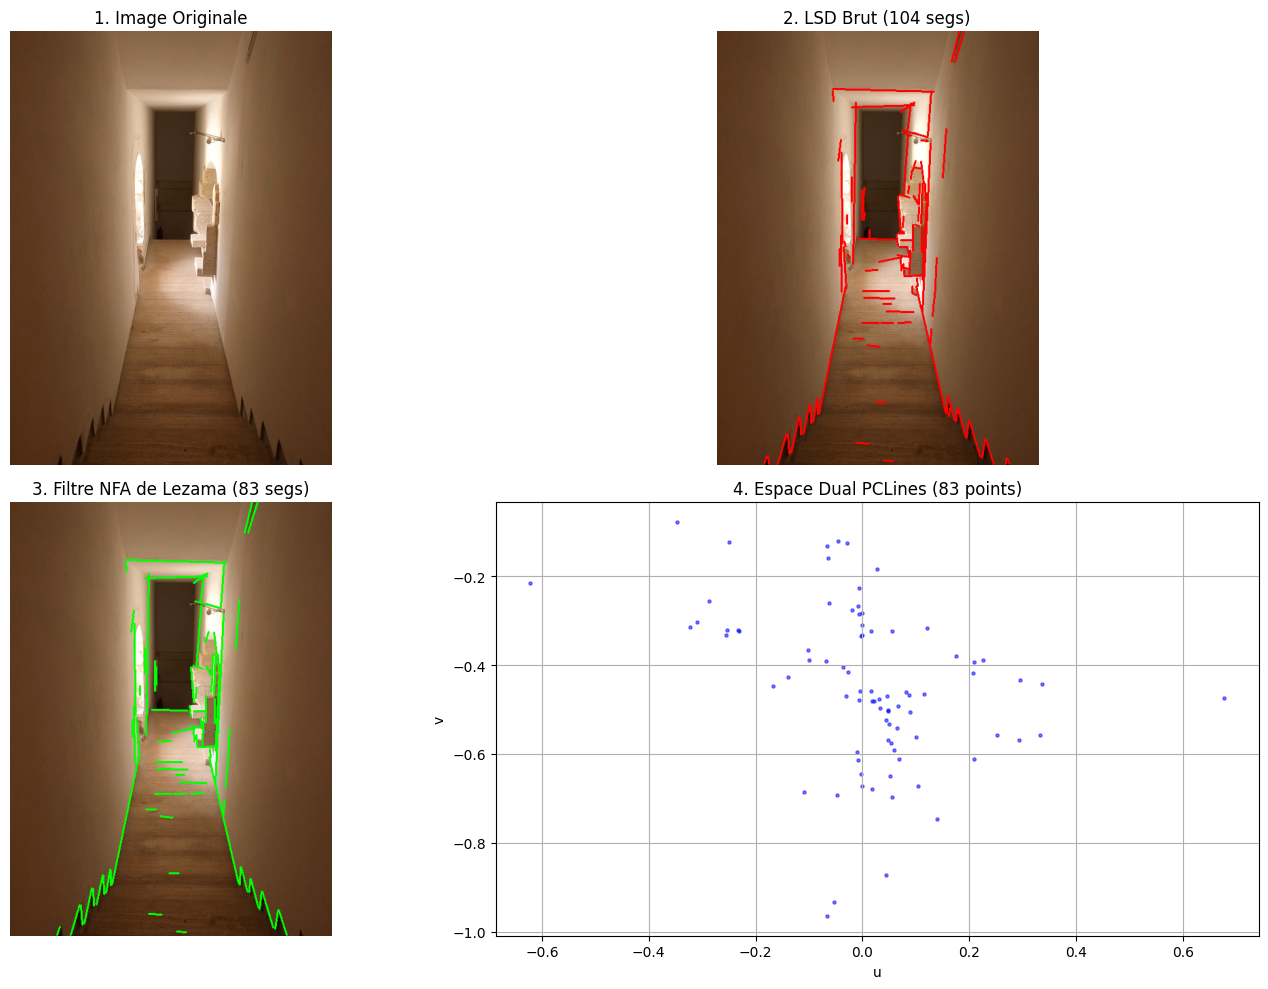

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def nfa_lezama(length, img_width, img_height):
    """ Calcule le Log10(NFA) d'un segment selon Lezama. """
    p = 0.125  # Probabilité d'alignement par hasard
    # Nombre de rectangles potentiels (N^4 approx)
    N_tests = (img_width * img_height)**2 
    # Formule : Log10(NFA) = Log10(N_tests) + length * Log10(p)
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

def compute_pclines_dual(lines, img_w, img_h):
    """ Transforme les segments en points dans l'espace dual PCLines. """
    points_dual = []
    d = max(img_w, img_h) # Échelle pour l'espace dual
    
    for l in lines:
        x1, y1, x2, y2 = l[0]
        # Équation de la droite : ax + by + c = 0
        a, b = y1 - y2, x2 - x1
        c = x1*y2 - x2*y1
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        
        # Transformation PCLines Straight/Twisted (Sect 2.2.3)
        if abs(a) > abs(b): # Plutôt verticale -> Straight
            u, v = b / a, c / (a * d)
        else: # Plutôt horizontale -> Twisted
            u, v = a / b, c / (b * d)
        points_dual.append([u, v])
    return np.array(points_dual)

# --- PIPELINE VISUELLE ---

# 1. Charger l'image (Cas B: Couloir)
img_bgr = cv2.imread('couloir.jpg')
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
h, w = img_gray.shape

# ÉTAPE 1 : LSD Brut
lsd = cv2.createLineSegmentDetector(0)
lines_brut, _, _, _ = lsd.detect(img_gray)
img_lsd = img_bgr.copy()
if lines_brut is not None:
    for l in lines_brut:
        x1, y1, x2, y2 = map(int, l[0])
        cv2.line(img_lsd, (x1, y1), (x2, y2), (0, 0, 255), 2) # Rouge

# ÉTAPE 2 : Filtre NFA (Nettoyage de Lezama)
lines_valid = []
if lines_brut is not None:
    for l in lines_brut:
        x1, y1, x2, y2 = l[0]
        length = np.sqrt((x2-x1)**2 + (y2-y1)**2)
        # On ne garde que si NFA < 1 (Log10 < 0)
        if nfa_lezama(length, w, h) < 0:
            lines_valid.append(l)

img_nfa = img_bgr.copy()
for l in lines_valid:
    x1, y1, x2, y2 = map(int, l[0])
    cv2.line(img_nfa, (x1, y1), (x2, y2), (0, 255, 0), 2) # Vert

# ÉTAPE 3 : Espace Dual PCLines
dual_space = compute_pclines_dual(lines_valid, w, h)

# --- AFFICHAGE DE TOUTES LES ÉTAPES ---
plt.figure(figsize=(15, 10))

# Affichage Image Originale
plt.subplot(2, 2, 1)
plt.imshow(cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB))
plt.title("1. Image Originale")
plt.axis('off')

# Affichage LSD Brut (Tes 102 segments)
plt.subplot(2, 2, 2)
plt.imshow(cv2.cvtColor(img_lsd, cv2.COLOR_BGR2RGB))
plt.title(f"2. LSD Brut ({len(lines_brut) if lines_brut is not None else 0} segs)")
plt.axis('off')

# Affichage Filtre NFA (Tes 82 segments)
plt.subplot(2, 2, 3)
plt.imshow(cv2.cvtColor(img_nfa, cv2.COLOR_BGR2RGB))
plt.title(f"3. Filtre NFA de Lezama ({len(lines_valid)} segs)")
plt.axis('off')

# Affichage Espace Dual (Le nuage de points)
plt.subplot(2, 2, 4)
plt.scatter(dual_space[:, 0], dual_space[:, 1], s=5, c='blue', alpha=0.5)
plt.title(f"4. Espace Dual PCLines ({len(dual_space)} points)")
plt.xlabel("u")
plt.ylabel("v")
plt.grid(True)

plt.tight_layout()
plt.show()

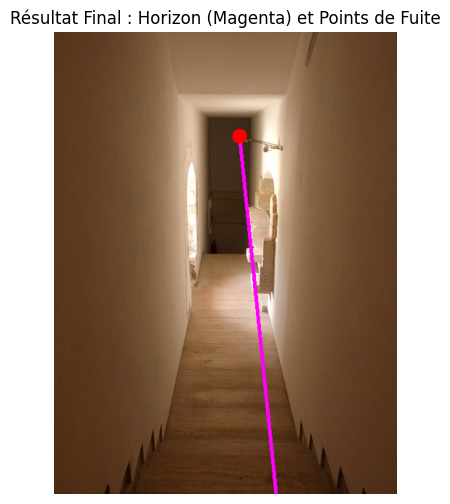

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import RANSACRegressor

# --- FONCTIONS DE BASE ---

def nfa_lezama(length, img_width, img_height):
    p = 0.125
    N_tests = (img_width * img_height)**2
    log10_nfa = np.log10(N_tests) + length * np.log10(p)
    return log10_nfa

def compute_pclines_dual(lines, img_w, img_h):
    points_dual = []
    d = max(img_w, img_h)
    for l in lines:
        x1, y1, x2, y2 = l[0]
        a, b = y1 - y2, x2 - x1
        c = x1*y2 - x2*y1
        norm = np.sqrt(a**2 + b**2)
        if norm == 0: continue
        a, b, c = a/norm, b/norm, c/norm
        if abs(a) > abs(b): # Straight
            u, v = b / a, c / (a * d)
        else: # Twisted
            u, v = a / b, c / (b * d)
        points_dual.append([u, v])
    return np.array(points_dual), d

# --- LOGIQUE FINALE : DÉTECTION DES VP ET HORIZON ---

def get_vp_from_dual_line(m, c, d):
    """ Convertit une ligne v = mu + c du dual en coordonnées image (x, y) """
    # Basé sur la transformation inverse de PCLines
    y = -m * d
    x = -c * d
    return int(x), int(y)

# 1. Chargement et Prétraitement
img = cv2.imread('couloir.jpg') # Ton image de couloir
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
h, w = gray.shape

# 2. LSD + NFA (Nettoyage)
lsd = cv2.createLineSegmentDetector(0)
lines_brut, _, _, _ = lsd.detect(gray)
valid_lines = [l for l in lines_brut if nfa_lezama(np.linalg.norm(l[0][:2]-l[0][2:]), w, h) < 0]

# 3. Passage au Domaine Dual
dual_pts, d_scale = compute_pclines_dual(valid_lines, w, h)

# 4. Détection des 2 VP principaux (Horizontaux) dans le Dual
# On utilise RANSAC pour trouver les deux lignes les plus fortes dans le nuage de points
vps = []
remaining_pts = dual_pts.copy()

for _ in range(2): # On cherche les 2 directions horizontales
    if len(remaining_pts) < 10: break
    ransac = RANSACRegressor()
    X = remaining_pts[:, 0].reshape(-1, 1)
    y = remaining_pts[:, 1]
    ransac.fit(X, y)
    
    # Récupération des paramètres de la ligne v = mu + c
    m = ransac.estimator_.coef_[0]
    c = ransac.estimator_.intercept_
    
    # Conversion en VP (x, y)
    vps.append(get_vp_from_dual_line(m, c, d_scale))
    
    # On retire les points utilisés pour trouver le VP suivant
    remaining_pts = remaining_pts[~ransac.inlier_mask_]

# --- AFFICHAGE FINAL ---
img_final = img.copy()

# Dessiner la ligne d'horizon (relie les deux VP horizontaux)
if len(vps) >= 2:
    cv2.line(img_final, vps[0], vps[1], (255, 0, 255), 4) # Ligne Magenta
    cv2.circle(img_final, vps[0], 10, (0, 0, 255), -1)
    cv2.circle(img_final, vps[1], 10, (255, 0, 0), -1)

plt.figure(figsize=(10, 6))
plt.imshow(cv2.cvtColor(img_final, cv2.COLOR_BGR2RGB))
plt.title("Résultat Final : Horizon (Magenta) et Points de Fuite")
plt.axis('off')
plt.savefig('resultat_final_lezama.png')

A partir de là

In [12]:
import cv2
import numpy as np

# Charger l'image
img = cv2.imread("couloir.jpg", cv2.IMREAD_GRAYSCALE)

# Créer le détecteur LSD
lsd = cv2.createLineSegmentDetector(0)

# Détecter les lignes
lines, widths, precisions, _ = lsd.detect(img)

# lines est un tableau (N, 1, 4) : x1,y1,x2,y2
lines = lines[:,0,:]  # pour simplifier

print(f"{len(lines)} segments détectés")

102 segments détectés


In [5]:
import numpy as np
from scipy.stats import binom

# -----------------------------
# Fonctions utilitaires
# -----------------------------
def segment_orientation(line):
    x1, y1, x2, y2 = line
    return np.arctan2(y2 - y1, x2 - x1)

def segment_length(line):
    x1, y1, x2, y2 = line
    return np.hypot(x2 - x1, y2 - y1)

def sample_endpoints(line):
    x1, y1, x2, y2 = line
    return np.array([[x1, y1], [x2, y2]])

# -----------------------------
# NFA robust
# -----------------------------
def compute_p(box_area, R_area, N_R):
    """Probabilité qu'une boîte soit occupée"""
    q = box_area / R_area
    return 1 - (1 - q) ** N_R

def compute_B_tail(c, b, p):
    """Queue binomiale P(X >= b)"""
    return binom.sf(b-1, c, p)

def compute_logNFA(b, c, p, N, W, L, C):
    """
    b : nombre de cases occupées
    c : nombre de cases
    p : probabilité qu'une case soit occupée
    N : nombre total de points
    W : nombre de largeurs testées
    L : nombre de positions locales testées
    C : nombre de valeurs de c testées
    """
    log_B = np.log(compute_B_tail(c, b, p))
    log_N_tests = np.log(N*(N-1)/2) + np.log(W) + np.log(L) + np.log(C)
    return log_N_tests + log_B

# -----------------------------
# Point alignment detector
# -----------------------------
def point_alignment_detector(points, R_area, box_area, c=6, W=3, L=3, C=1, epsilon=1):
    """
    points : Nx2 array
    Retourne des alignements significatifs
    """
    N = len(points)
    alignments = []

    for i in range(N):
        for j in range(i+1, N):
            rect_points = np.array([points[i], points[j]])
            
            # vrai nombre de boxes occupées
            x_min, x_max = np.min(rect_points[:,0]), np.max(rect_points[:,0])
            boxes = np.linspace(x_min, x_max, c+1)
            b_obs = sum(np.any((rect_points[:,0] >= boxes[k]) & (rect_points[:,0] < boxes[k+1])) for k in range(c))
            
            N_R = N  # simplification : tous les points dans R
            p = compute_p(box_area, R_area, N_R)
            
            lognfa = compute_logNFA(b_obs, c, p, N, W, L, C)
            if lognfa <= np.log(epsilon):
                alignments.append([points[i], points[j]])
    return alignments

# -----------------------------
# Pipeline complet : améliorer segments
# -----------------------------
def improve_segments_with_alignment(segments, length_thresh=30, angle_step=np.pi/6,
                                   box_area=1, R_area=100, c=6,
                                   W=3, L=3, C=1, epsilon=1):
    # Séparer longs et courts
    long_segments, short_segments = [], []
    for seg in segments:
        if segment_length(seg) >= length_thresh:
            long_segments.append(seg)
        else:
            short_segments.append(seg)
    
    long_segments = np.array(long_segments)
    short_segments = np.array(short_segments)
    
    # Grouper par orientation
    all_groups = []
    for angle_bin in np.arange(-np.pi/2, np.pi/2, angle_step):
        group = []
        for seg in np.vstack([short_segments, long_segments]):
            theta = segment_orientation(seg)
            if abs(theta - angle_bin) <= angle_step/2:
                group.append(seg)
        if group:
            all_groups.append(np.array(group))
    
    # Pour chaque groupe, détecter alignements sur endpoints
    new_segments = []
    for group in all_groups:
        endpoints = np.vstack([sample_endpoints(seg) for seg in group])
        alignments = point_alignment_detector(endpoints, R_area, box_area, c, W, L, C, epsilon)
        for pair in alignments:
            p1, p2 = pair
            new_segments.append([p1[0], p1[1], p2[0], p2[1]])
    
    # Segments finaux = longs originaux + segments issus des alignements
    if new_segments:
        final_segments = np.vstack([long_segments, np.array(new_segments)])
    else:
        final_segments = long_segments
    return final_segments

# -----------------------------
# Exemple d'utilisation
# -----------------------------




final_segments = improve_segments_with_alignment(lines)
print("Segments finaux améliorés :")

print(len(final_segments))

Segments finaux améliorés :
41


In [ ]:
import numpy as np
from scipy.stats import binom

# -----------------------------
# Fonctions utilitaires
# -----------------------------
def segment_orientation(line):
    x1, y1, x2, y2 = line
    return np.arctan2(y2 - y1, x2 - x1)

def segment_length(line):
    x1, y1, x2, y2 = line
    return np.hypot(x2 - x1, y2 - y1)

def sample_endpoints(line):
    x1, y1, x2, y2 = line
    return np.array([[x1, y1], [x2, y2]])

def count_points_in_box(points, x_edges, y_edges):
    """Compter combien de boxes sont occupées"""
    b = 0
    for i in range(len(x_edges)-1):
        for j in range(len(y_edges)-1):
            if np.any((points[:,0] >= x_edges[i]) & (points[:,0] < x_edges[i+1]) &
                      (points[:,1] >= y_edges[j]) & (points[:,1] < y_edges[j+1])):
                b += 1
    return b

# -----------------------------
# NFA robust
# -----------------------------
def compute_p(box_area, R_area, N_R):
    q = box_area / R_area
    return 1 - (1 - q) ** N_R

def compute_B_tail(c, b, p):
    return binom.sf(b-1, c, p)

def compute_logNFA(b, c, p, N, W, L, C):
    log_B = np.log(compute_B_tail(c, b, p))
    log_N_tests = np.log(N*(N-1)/2) + np.log(W) + np.log(L) + np.log(C)
    return log_N_tests + log_B

# -----------------------------
# Point alignment detector complet
# -----------------------------
def point_alignment_detector(points, R_area, box_area, c_list=[6], W=3, L=3, C=1, epsilon=1):
    """
    points : Nx2 array
    c_list : liste de valeurs de c à tester
    W : nombre de largeurs de rectangles à tester
    L : nombre de positions locales à tester
    C : nombre de valeurs de c à tester (ou len(c_list))
    """
    N = len(points)
    alignments = []
    points = np.vstack([lines[:, :2], lines[:, 2:]])

    for i in range(N):
        for j in range(i+1, N):
            # Créer rectangle minimal pour points i,j
            pt1, pt2 = points[i], points[j]
            rect_widths = np.linspace(0.5, 1.5, W)  # facteur multiplicatif sur la largeur
            best_logNFA = np.inf
            best_pair = None

            for w_factor in rect_widths:
                # largeur du rectangle candidate = distance i-j * w_factor
                dx, dy = pt2 - pt1
                x_center, y_center = (pt1 + pt2)/2
                rect_length = np.hypot(dx, dy)
                rect_w = rect_length * w_factor

                # Tester L positions locales autour du centre
                for l_shift in np.linspace(-rect_length/4, rect_length/4, L):
                    x_shifted = x_center + l_shift
                    y_shifted = y_center + l_shift  # simple approximation

                    for c in c_list:
                        # Diviser rectangle en c x c boxes
                        x_edges = np.linspace(x_center - rect_w/2, x_center + rect_w/2, c+1)
                        y_edges = np.linspace(y_center - rect_w/2, y_center + rect_w/2, c+1)
                        b_obs = count_points_in_box(points, x_edges, y_edges)

                        # Nombre de points dans la fenêtre locale R (simplification: tous les points)
                        N_R = N
                        p = compute_p(box_area, R_area, N_R)

                        lognfa = compute_logNFA(b_obs, c, p, N, W, L, C)
                        if lognfa < best_logNFA:
                            best_logNFA = lognfa
                            best_pair = [pt1, pt2]

            # Si NFA minimale ≤ epsilon, garder l'alignement
            if best_logNFA <= np.log(epsilon):
                alignments.append(best_pair)

    return alignments

# -----------------------------
# Exemple d'utilisation
# -----------------------------


alignments = point_alignment_detector(lines, R_area=100, box_area=1, c_list=[6], W=3, L=3, C=1, epsilon=1)
print("Alignements détectés :")
for a in alignments:
    print(a)


C:\Users\athee\AppData\Local\Temp\ipykernel_92036\3333450826.py:40: RuntimeWarning: divide by zero encountered in log
  log_B = np.log(compute_B_tail(c, b, p))


Alignements détectés :
[array([266.5417 , 243.06192], dtype=float32), array([264.67114, 300.46912], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([275.6243 , 298.76236], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([308.10852, 253.06366], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([283.0132 , 358.11975], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([269.67944, 293.74695], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([310.70587, 162.1539 ], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([293.27063, 376.841  ], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([280.64392, 318.1231 ], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([298.4355 , 225.59558], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), array([300.82626, 284.40646], dtype=float32)]
[array([266.5417 , 243.06192], dtype=float32), 

In [14]:
import numpy as np
from scipy.stats import binom

# -----------------------------
# Fonctions utilitaires
# -----------------------------
def segment_orientation(line):
    x1, y1, x2, y2 = line
    return np.arctan2(y2 - y1, x2 - x1)

def segment_length(line):
    x1, y1, x2, y2 = line
    return np.hypot(x2 - x1, y2 - y1)

def sample_endpoints(segments):
    """Retourne tous les endpoints des segments Nx4 -> 2N x 2"""
    return np.vstack([segments[:, :2], segments[:, 2:]])

def count_points_in_box(points, x_edges, y_edges):
    b = 0
    for i in range(len(x_edges)-1):
        for j in range(len(y_edges)-1):
            if np.any((points[:,0] >= x_edges[i]) & (points[:,0] < x_edges[i+1]) &
                      (points[:,1] >= y_edges[j]) & (points[:,1] < y_edges[j+1])):
                b += 1
    return b

def compute_p(box_area, R_area, N_R):
    q = box_area / R_area
    return 1 - (1 - q) ** N_R

def compute_B_tail(c, b, p):
    return binom.sf(b-1, c, p)

def compute_logNFA(b, c, p, N, W, L, C):
    log_B = np.log(compute_B_tail(c, b, p))
    log_N_tests = np.log(N*(N-1)/2) + np.log(W) + np.log(L) + np.log(C)
    return log_N_tests + log_B

# -----------------------------
# Point Alignment Detector complet
# -----------------------------
def point_alignment_detector(points, R_area, box_area, c_list=[6], W=3, L=3, C=1, epsilon=1):
    N = len(points)
    alignments = []

    for i in range(N):
        for j in range(i+1, N):
            pt1, pt2 = points[i], points[j]
            best_logNFA = np.inf
            best_pair = None

            # Boucle sur W largeurs différentes
            for w_factor in np.linspace(0.5, 1.5, W):
                dx, dy = pt2 - pt1
                x_center, y_center = (pt1 + pt2)/2
                rect_length = np.hypot(dx, dy)
                rect_w = rect_length * w_factor

                # Boucle sur L positions locales
                for l_shift in np.linspace(-rect_length/4, rect_length/4, L):
                    x_shifted = x_center + l_shift
                    y_shifted = y_center + l_shift  # approximation simple

                    # Boucle sur C valeurs de c
                    for c in c_list:
                        x_edges = np.linspace(x_center - rect_w/2, x_center + rect_w/2, c+1)
                        y_edges = np.linspace(y_center - rect_w/2, y_center + rect_w/2, c+1)
                        b_obs = count_points_in_box(points, x_edges, y_edges)

                        N_R = N  # simplification : tous les points dans R
                        p = compute_p(box_area, R_area, N_R)

                        lognfa = compute_logNFA(b_obs, c, p, N, W, L, C)
                        if lognfa < best_logNFA:
                            best_logNFA = lognfa
                            best_pair = [pt1, pt2]

            # Garde l'alignement si NFA <= epsilon
            if best_logNFA <= np.log(epsilon):
                alignments.append(best_pair)

    return alignments

# -----------------------------
# Masquage des segments redondants
# -----------------------------
def mask_segments(segments, overlap_threshold=0.5):
    final_segments = []
    for s in segments:
        s_points = [tuple(s[:2]), tuple(s[2:])]  # deux endpoints
        masked = False
        for fs in final_segments:
            fs_points = [tuple(fs[:2]), tuple(fs[2:])]
            overlap = len(set(s_points) & set(fs_points)) / 2  # nombre de points communs / 2
            if overlap >= overlap_threshold:
                masked = True
                break
        if not masked:
            final_segments.append(s)
    return final_segments

# -----------------------------
# Pipeline complet
# -----------------------------
def improve_segments_with_alignment(lines, length_thresh=30, angle_step=np.pi/6,
                                   box_area=1, R_area=100, c_list=[6],
                                   W=3, L=3, C=1, epsilon=1):

    # Séparer segments longs / courts
    long_segments = []
    short_segments = []
    for seg in lines:
        if segment_length(seg) >= length_thresh:
            long_segments.append(seg)
        else:
            short_segments.append(seg)
    long_segments = np.array(long_segments)
    short_segments = np.array(short_segments)

    # Grouper par orientation
    all_groups = []
    for angle_bin in np.arange(-np.pi/2, np.pi/2, angle_step):
        group = []
        for seg in np.vstack([short_segments, long_segments]):
            theta = segment_orientation(seg)
            if abs(theta - angle_bin) <= angle_step/2:
                group.append(seg)
        if group:
            all_groups.append(np.array(group))

    # Détecter alignements sur les endpoints
    new_segments = []
    for group in all_groups:
        endpoints = sample_endpoints(group)
        alignments = point_alignment_detector(endpoints, R_area, box_area, c_list, W, L, C, epsilon)
        for pair in alignments:
            p1, p2 = pair
            new_segments.append([p1[0], p1[1], p2[0], p2[1]])

    # Appliquer masking pour réduire redondances
    new_segments = mask_segments(new_segments)

    # Segments finaux = longs originaux + segments issus des alignements
    if len(new_segments) > 0:
        final_segments = np.vstack([long_segments, np.array(new_segments)])
    else:
        final_segments = long_segments
    return final_segments

# -----------------------------
# Exemple d'utilisation
# -----------------------------


final_segments = improve_segments_with_alignment(lines)
print("Segments finaux améliorés :")
print(final_segments)

C:\Users\athee\AppData\Local\Temp\ipykernel_92036\1148167492.py:36: RuntimeWarning: divide by zero encountered in log
  log_B = np.log(compute_B_tail(c, b, p))


Segments finaux améliorés :
[[2.66541687e+02 2.43061920e+02 2.70148895e+02 2.95485748e+02]
 [3.08108521e+02 2.53063660e+02 3.02599792e+02 3.66789001e+02]
 [2.83013214e+02 3.58119751e+02 2.84653290e+02 3.23138062e+02]
 [2.93270630e+02 3.76841003e+02 3.00849945e+02 4.09322510e+02]
 [2.98435486e+02 2.25595581e+02 2.97495667e+02 2.55605286e+02]
 [3.00826263e+02 2.84406464e+02 3.02100983e+02 2.25629898e+02]
 [2.88351379e+02 3.24378571e+02 2.88964172e+02 2.85638275e+02]
 [2.00840775e+02 3.43187683e+02 2.04592834e+02 1.05766724e+02]
 [3.00525635e+02 1.92792236e+02 3.04869934e+02 2.24133133e+02]
 [3.02412567e+02 4.14280457e+02 3.14391479e+02 1.65625793e+02]
 [2.61880646e+02 3.07142731e+02 2.08125244e+02 3.06833557e+02]
 [1.83904999e+02 1.79403030e+02 1.84793442e+02 3.13130524e+02]
 [2.81906433e+02 1.52704346e+02 2.74456024e+02 2.42821671e+02]
 [1.90475586e+02 3.79306519e+02 1.86665237e+02 3.18060272e+02]
 [3.10180084e+02 1.54446503e+02 3.15996246e+02 8.89638748e+01]
 [2.72218170e+02 3.33511780

In [15]:
print(len(alignments))

4980


In [18]:
import numpy as np

# -----------------------------
# Transformations PClines
# -----------------------------
def point_to_dual_straight(A, d=1):
    """
    Transforme un point A=(x,y) en ligne dans le dual space (straight)
    Ligne passant par (0,x) et (d,y)
    """
    x, y = A
    # On renvoie (slope, intercept) de la ligne u -> v : v = m*u + b
    m = (y - x) / d
    b = x
    return m, b

def point_to_dual_twisted(A, d=1):
    """
    Transforme un point A=(x,y) en ligne dans le dual space (twisted)
    Ligne passant par (0,x) et (d,-y)
    """
    x, y = A
    m = (-y - x) / d
    b = x
    return m, b

# -----------------------------
# Intersection de deux lignes dans dual space
# -----------------------------
def intersect_lines_dual(line1, line2):
    m1, b1 = line1
    m2, b2 = line2
    if m1 == m2:
        return None  # lignes parallèles → pas d'intersection
    u = (b2 - b1) / (m1 - m2)
    v = m1 * u + b1
    return np.array([u, v])

# -----------------------------
# Transformation des segments en points dual space
# -----------------------------
def segments_to_dual_points(segments, transform='straight', d=1, domain=[-1,2]):
    """
    segments : Nx4
    transform : 'straight' ou 'twisted'
    domain : limites [min,max] pour u et v
    Retourne tous les points candidats dans le dual space
    """
    points_dual = []
    for seg in segments:
        A = seg[:2]
        B = seg[2:]
        # Transformer chaque endpoint en ligne dual space
        if transform == 'straight':
            l1 = point_to_dual_straight(A, d)
            l2 = point_to_dual_straight(B, d)
        else:
            l1 = point_to_dual_twisted(A, d)
            l2 = point_to_dual_twisted(B, d)
        # Intersection → point dual
        pt = intersect_lines_dual(l1, l2)
        if pt is not None:
            u, v = pt
            if domain[0] <= u <= domain[1] and domain[0] <= v <= domain[1]:
                points_dual.append(pt)
    return np.array(points_dual)

# -----------------------------
# Détection des VPs
# -----------------------------
def detect_vanishing_points(final_segments, R_area=100, box_area=1, c_list=[6], 
                            W=3, L=3, C=1, epsilon=1, d=1, delta=0.05):
    """
    Pipeline complet PClines straight + twisted
    Retourne VP candidats et NFA associés
    """
    # 1. Transform straight
    points_straight = segments_to_dual_points(final_segments, 'straight', d, domain=[-1,2])
    vp_straight = point_alignment_detector(points_straight, R_area, box_area, c_list, W, L, C, epsilon)

    # 2. Transform twisted
    points_twisted = segments_to_dual_points(final_segments, 'twisted', d, domain=[-2,1])
    vp_twisted = point_alignment_detector(points_twisted, R_area, box_area, c_list, W, L, C, epsilon)

    # 3. Convert dual points en VPs image
    # Chaque alignement dans dual space correspond à un VP candidat
    def dual_to_vp(pt_dual, transform='straight', d=1):
        u, v = pt_dual
        if transform == 'straight':
            # v = m*u + b → en image on approxime VP à (Ax, Ay)
            # Ici simplification : retourne (v,u)
            return np.array([v, u])
        else:
            return np.array([v, -u])

    vp_candidates = []
    nfa_values = []

    # Straight
    for pair in vp_straight:
        p1, p2 = pair
        vp_candidates.append(dual_to_vp(p2, 'straight'))
        nfa_values.append(0)  # placeholder, si on veut NFA réel on peut le calculer

    # Twisted
    for pair in vp_twisted:
        p1, p2 = pair
        vp_candidates.append(dual_to_vp(p2, 'twisted'))
        nfa_values.append(0)

    vp_candidates = np.array(vp_candidates)

    # 4. Fusion des VP similaires (distance < delta)
    final_vps = []
    for i, vp in enumerate(vp_candidates):
        keep = True
        for fv in final_vps:
            if np.linalg.norm(vp - fv) < delta:
                keep = False
                break
        if keep:
            final_vps.append(vp)
    final_vps = np.array(final_vps)
    return final_vps

# -----------------------------
# Exemple d'utilisation
# -----------------------------
# alignments = [[pt1, pt2], [pt3, pt4], ...]
final_segments_from_alignments = np.array([[p[0][0], p[0][1], p[1][0], p[1][1]] for p in alignments])
vps = detect_vanishing_points(final_segments_from_alignments)
print("VP candidats détectés :")
print(vps)

VP candidats détectés :
[[ 0.3272705  -0.478061  ]
 [-0.24606323 -0.43801165]
 [ 0.54574585 -0.65777665]
 [-0.35934448 -0.38309032]
 [ 0.62246704 -0.3750165 ]
 [-1.5282898  -0.43612793]
 [-0.7632446  -0.48069665]]


C:\Users\athee\AppData\Local\Temp\ipykernel_92036\1148167492.py:36: RuntimeWarning: divide by zero encountered in log
  log_B = np.log(compute_B_tail(c, b, p))


In [23]:
import numpy as np

def refine_vp(segments, vp_candidates, angle_thresh_deg=10):
    """
    segments: Nx4 array [[x1, y1, x2, y2], ...]
    vp_candidates: list of candidate VPs [[vx, vy, NFA], ...]
    angle_thresh_deg: seuil pour considérer un segment comme consistant
    """
    refined_vps = []
    for vp in vp_candidates:
        vx, vy= vp
        consistent_segments = []
        
        for seg in segments:
            x1, y1, x2, y2 = seg
            # centre du segment
            cx, cy = (x1+x2)/2, (y1+y2)/2
            # direction segment
            dx, dy = x2-x1, y2-y1
            seg_angle = np.arctan2(dy, dx)
            # direction centre -> VP
            vp_dx, vp_dy = vx-cx, vy-cy
            vp_angle = np.arctan2(vp_dy, vp_dx)
            # angle entre segment et VP
            angle_diff = np.abs(seg_angle - vp_angle)
            angle_diff = np.minimum(angle_diff, np.pi - angle_diff)
            
            if np.degrees(angle_diff) <= angle_thresh_deg:
                consistent_segments.append(seg)
        
        if len(consistent_segments) > 0:
            # raffiner VP : moyenne pondérée par longueur des segments
            points = []
            weights = []
            for seg in consistent_segments:
                x1, y1, x2, y2 = seg
                length = np.hypot(x2-x1, y2-y1)
                points.append([x1, y1])
                points.append([x2, y2])
                weights.extend([length, length])
            points = np.array(points)
            weights = np.array(weights)
            vx_refined = np.average(points[:,0], weights=weights)
            vy_refined = np.average(points[:,1], weights=weights)
            refined_vps.append([vx_refined, vy_refined, nfa])
        else:
            refined_vps.append(vp)
    return refined_vps

In [25]:
refined_vps = refine_vp(final_segments, vps, angle_thresh_deg=10)

print("VP raffinés :")
for vp in refined_vps:
    print(f"x={vp[0]:.2f}, y={vp[1]:.2f}")

VP raffinés :
x=0.33, y=-0.48
x=-0.25, y=-0.44
x=0.55, y=-0.66
x=-0.36, y=-0.38
x=0.62, y=-0.38
x=-1.53, y=-0.44
x=-0.76, y=-0.48


In [28]:
def select_final_vp_triplet(vps, gamma=5):
    """
    vps : liste de VPs candidats [[x, y, logNFA], ...] ou [[x,y], ...]
    gamma : tolérance angle orthogonal (deg)
    """
    best_triplet = None
    best_pair = None  # <- important !
    n = len(vps)
    vps = np.array(vps)
    
    # convertir en vecteurs unitaires
    unit_vecs = np.array([v/np.linalg.norm(v) for v in vps[:,:2]])

    # test tous les triplets
    for i in range(n):
        for j in range(i+1, n):
            for k in range(j+1, n):
                u1, u2, u3 = unit_vecs[i], unit_vecs[j], unit_vecs[k]
                angles = [
                    np.arccos(np.clip(np.dot(u1,u2), -1,1)),
                    np.arccos(np.clip(np.dot(u1,u3), -1,1)),
                    np.arccos(np.clip(np.dot(u2,u3), -1,1))
                ]
                angles_deg = np.degrees(angles)
                if all(abs(a - 90) <= gamma for a in angles_deg):
                    best_triplet = [vps[i], vps[j], vps[k]]
                    return best_triplet  # on prend le premier valide
    
    # si aucun triplet, choisir le meilleur couple et cross product
    if best_triplet is None:
        for i in range(n):
            for j in range(i+1, n):
                best_pair = [vps[i], vps[j]]
                # cross product simplifié
                v1, v2 = unit_vecs[i], unit_vecs[j]
                v3 = np.cross(np.append(v1,0), np.append(v2,0))
                norm_v3 = np.linalg.norm(v3)
                if norm_v3 > 0:
                    v3 /= norm_v3
                    best_triplet = [best_pair[0], best_pair[1], [v3[0], v3[1], 0]]
                else:
                    best_triplet = [best_pair[0], best_pair[1], [0,0,0]]
                return best_triplet
    
    return best_triplet

In [29]:
# Triplet final de vanishing points
gamma = 5  # tolérance en degrés pour l'orthogonalité
final_vp_triplet = select_final_vp_triplet(refined_vps, gamma=gamma)

print("Triplet final de VPs :")
for i, vp in enumerate(final_vp_triplet):
    print(f"VP{i+1}: x={vp[0]:.2f}, y={vp[1]:.2f}")

Triplet final de VPs :
VP1: x=0.33, y=-0.48
VP2: x=-0.25, y=-0.44
VP3: x=0.00, y=-0.00


In [30]:
import numpy as np

def compute_horizon_line(vp_triplet):
    # Supposons que les deux VPs horizontaux sont vp1 et vp2
    vp1, vp2, vp3 = vp_triplet
    x1, y1 = vp1[:2]
    x2, y2 = vp2[:2]

    # Equation de la ligne : y = m*x + b
    m = (y2 - y1) / (x2 - x1 + 1e-8)  # éviter division par 0
    b = y1 - m * x1
    return m, b

In [32]:
import matplotlib.pyplot as plt

def plot_pipeline(segments, refined_vps, final_vp_triplet, img_shape=None):
    plt.figure(figsize=(12,8))
    
    # 1. Segments
    for seg in segments:
        x0, y0, x1, y1 = seg
        plt.plot([x0, x1], [y0, y1], 'b-', alpha=0.6)
    
    # 2. VPs raffinés
    for vp in refined_vps:
        x, y = vp[:2]
        plt.plot(x, y, 'ro')
        plt.text(x, y, f'({x:.2f},{y:.2f})', color='red')
    
    # 3. Triplet final
    colors = ['g','m','c']
    for i, vp in enumerate(final_vp_triplet):
        x, y = vp[:2]
        plt.plot(x, y, 'o', color=colors[i], markersize=10)
    
    # 4. Horizon line (si triplet Manhattan)
    m, b = compute_horizon_line(final_vp_triplet)
    xs = np.linspace(0, img_shape[1] if img_shape else 1000, 2)
    ys = m * xs + b
    plt.plot(xs, ys, 'k--', linewidth=2, label='Horizon')

    plt.gca().invert_yaxis()  # coord image
    plt.axis('equal')
    plt.legend()
    plt.show()

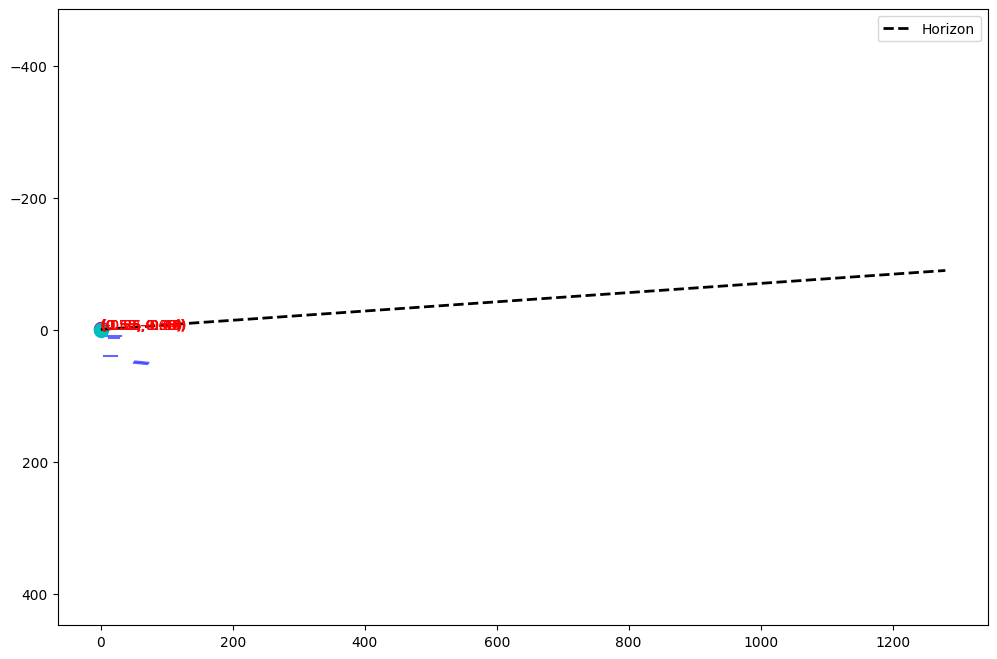

In [33]:
m, b = compute_horizon_line(final_vp_triplet)
plot_pipeline(final_segments, refined_vps, final_vp_triplet, img_shape=(720,1280))

In [34]:
import matplotlib.pyplot as plt

def visualize_pipeline(img, segments, aligned_segments, vp_candidates, refined_vps, final_vp_triplet):
    """
    Visualisation complète étape par étape sur l'image
    """
    plt.figure(figsize=(14,10))
    plt.imshow(img)
    
    # 1️⃣ Segments initiaux (LSD)
    for seg in segments:
        x0, y0, x1, y1 = seg
        plt.plot([x0, x1], [y0, y1], 'b-', alpha=0.3)
    
    # 2️⃣ Segments après alignement
    for seg in aligned_segments:
        x0, y0, x1, y1 = seg
        plt.plot([x0, x1], [y0, y1], 'g-', alpha=0.5)
    
    # 3️⃣ VPs candidats (dual space)
    for vp in vp_candidates:
        x, y = vp[:2]
        plt.plot(x, y, 'ro', markersize=6, alpha=0.6)
    
    # 4️⃣ VPs raffinés
    for vp in refined_vps:
        x, y = vp[:2]
        plt.plot(x, y, 'mo', markersize=8)
    
    # 5️⃣ Triplet final + horizon
    colors = ['c','y','lime']
    for i, vp in enumerate(final_vp_triplet):
        x, y = vp[:2]
        plt.plot(x, y, 'o', color=colors[i], markersize=12)
        plt.text(x+5, y+5, f'VP{i+1}', color=colors[i], fontsize=12)
    
    # Ligne d'horizon
    def compute_horizon_line(vp_triplet):
        vp1, vp2, _ = vp_triplet[:3]  # 2 horizontaux
        x1, y1 = vp1[:2]
        x2, y2 = vp2[:2]
        m = (y2 - y1) / (x2 - x1 + 1e-8)
        b = y1 - m * x1
        return m, b
    
    m, b = compute_horizon_line(final_vp_triplet)
    xs = np.linspace(0, img.shape[1], 2)
    ys = m * xs + b
    plt.plot(xs, ys, 'k--', linewidth=2, label='Horizon')
    
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.legend()
    plt.title("Pipeline complet de détection des VPs")
    plt.show()

In [45]:
import matplotlib.pyplot as plt
import numpy as np

def visualize_pipeline_step_by_step(img, segments, aligned_segments, vp_candidates, refined_vps, final_vp_triplet):
    """
    Visualisation étape par étape sur l'image
    """
    # 1️⃣ Segments initiaux (LSD)
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    for seg in segments:
        x0, y0, x1, y1 = seg
        plt.plot([x0, x1], [y0, y1], 'b-', alpha=0.3)
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.title("1️⃣ Segments initiaux (LSD)")
    plt.show()
    
    # 2️⃣ Segments après alignement
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    for seg in aligned_segments:
        x0, y0, x1, y1 = seg
        plt.plot([x0, x1], [y0, y1], 'g-', alpha=0.5)
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.title("2️⃣ Segments après alignement")
    plt.show()
    
    # 3️⃣ VPs candidats
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    for vp in vp_candidates:
        x, y = vp[:2]
        plt.plot(x, y, 'ro', markersize=6, alpha=0.6)
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.title("3️⃣ VPs candidats")
    plt.show()
    
    # 4️⃣ VPs raffinés
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    for vp in refined_vps:
        x, y = vp[:2]
        plt.plot(x, y, 'mo', markersize=8)
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.title("4️⃣ VPs raffinés")
    plt.show()
    
    # 5️⃣ Triplet final + horizon
    plt.figure(figsize=(10,8))
    plt.imshow(img)
    colors = ['c','y','lime']
    for i, vp in enumerate(final_vp_triplet):
        x, y = vp[:2]
        plt.plot(x, y, 'o', color=colors[i], markersize=12)
        plt.text(x+5, y+5, f'VP{i+1}', color=colors[i], fontsize=12)
    
    # Ligne d'horizon
    vp1, vp2, _ = final_vp_triplet[:3]  # 2 horizontaux
    x1, y1 = vp1[:2]
    x2, y2 = vp2[:2]
    m = (y2 - y1) / (x2 - x1 + 1e-8)
    b = y1 - m * x1
    xs = np.linspace(0, img.shape[1], 2)
    ys = m * xs + b
    plt.plot(xs, ys, 'k--', linewidth=2, label='Horizon')
    
    plt.gca().invert_yaxis()
    plt.axis('equal')
    plt.legend()
    plt.title("5️⃣ Triplet final et horizon")
    plt.show()

C:\Users\athee\AppData\Roaming\Python\Python310\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8419 (\N{COMBINING ENCLOSING KEYCAP}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


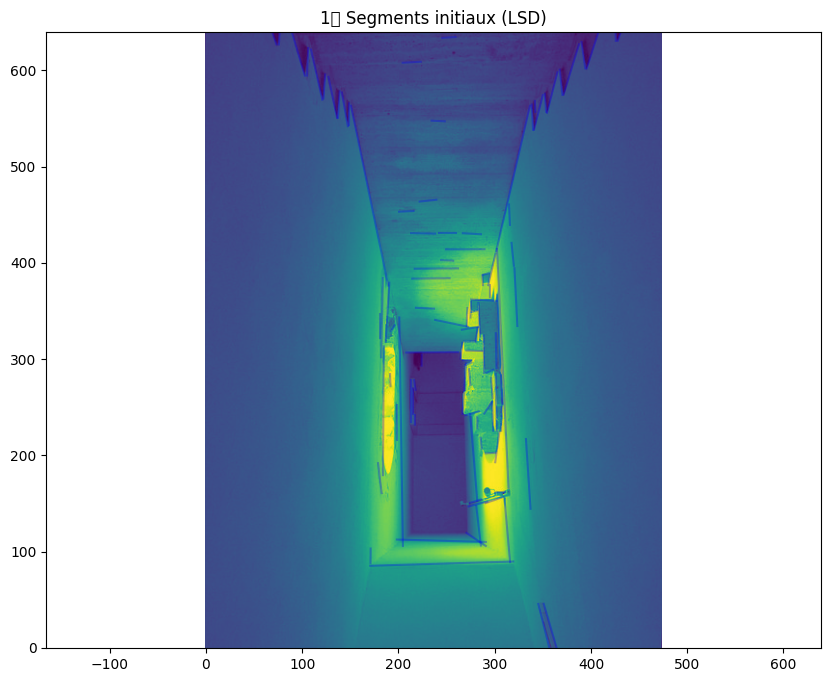

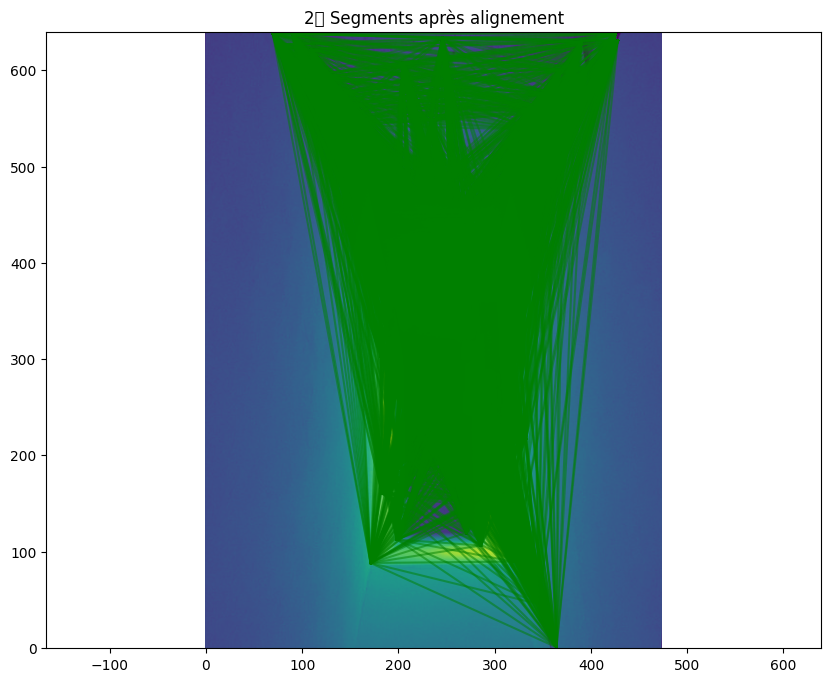

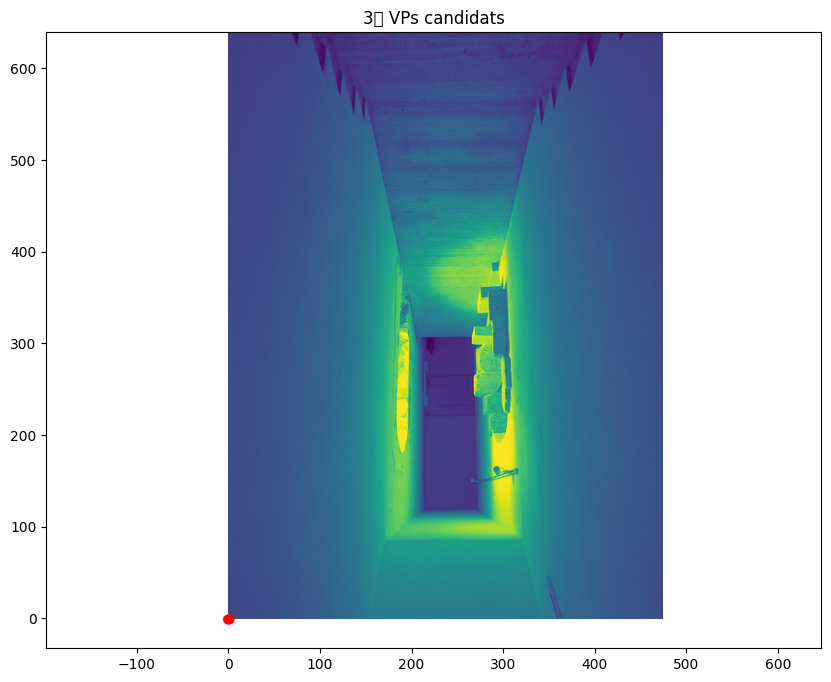

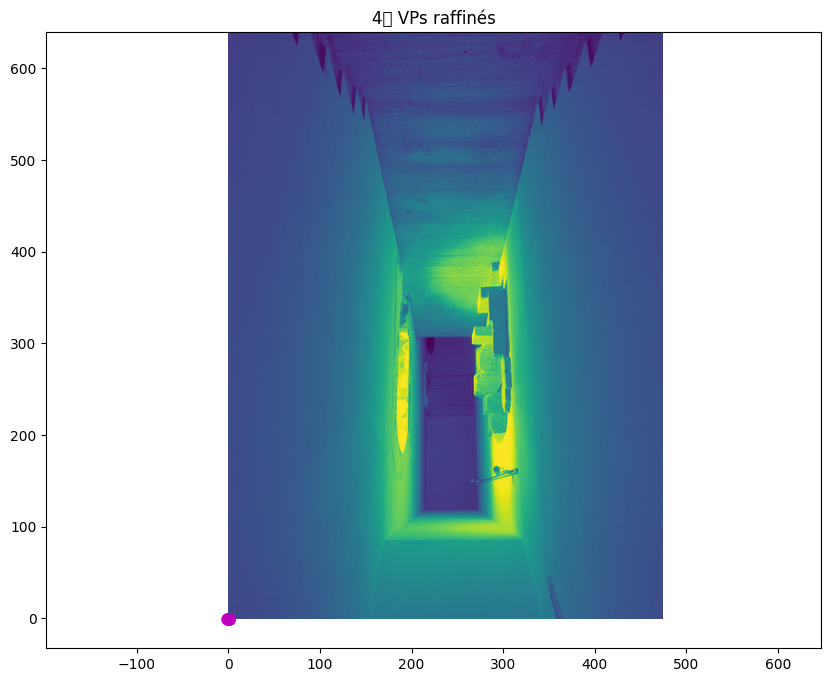

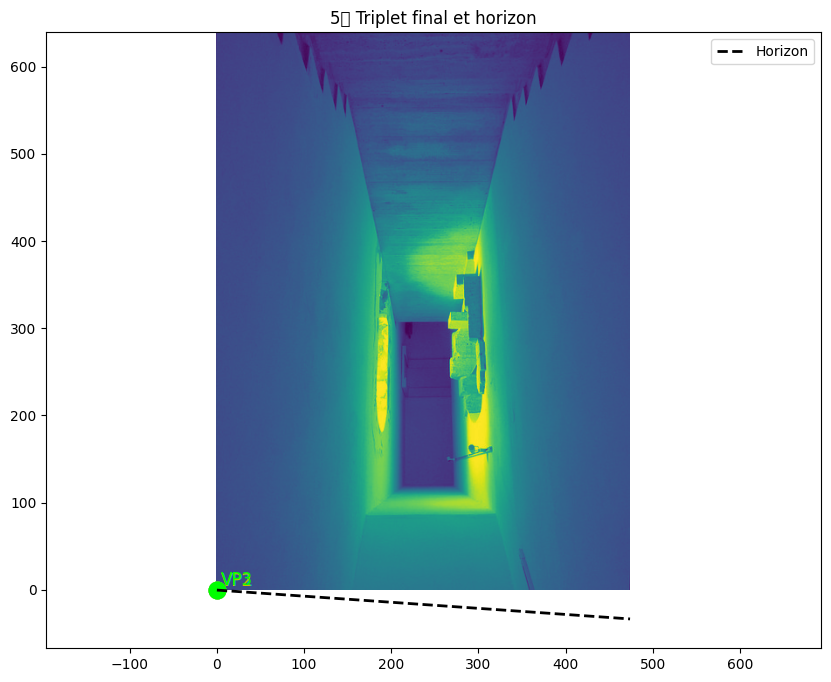

In [47]:
from PIL import Image
import numpy as np
img = cv2.imread("couloir.jpg", cv2.IMREAD_GRAYSCALE)

visualize_pipeline_step_by_step(
    img=img,
    segments=lines,
    aligned_segments=final_segments_from_alignments,
    vp_candidates=vps,
    refined_vps=refined_vps,
    final_vp_triplet=final_vp_triplet
)

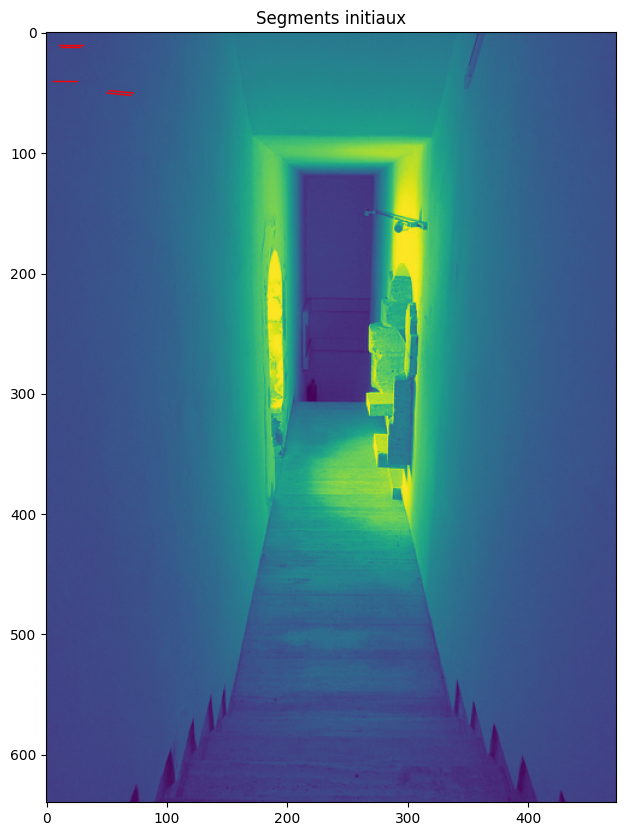

In [43]:
plt.figure(figsize=(14,10))
plt.imshow(img)
plt.title("Segments initiaux")
for seg in final_segments:
    x1, y1, x2, y2 = seg
    plt.plot([x1, x2], [y1, y2], 'r-', linewidth=1)

plt.show()